# Final Report: ChIP-seq Analysis of LEDGF-p75
**Student:** Kathleen Escobar | **Course:** NSBB552 | **Dataset:** Casiano Lab (2015)

## 1. Introduction and Methodology
**Objective:** To characterize the genomic occupancy of LEDGF-p75 and its transcriptional rewiring in drug-resistant (DR) prostate cancer cells.

**Hypothesis:** LEDGF/p75 maintains a conserved binding profile across cell lines, with enrichment at stress-response
genes in resistant lines.

**Methodology:**
The analysis pipeline follows a rigorous four-task protocol:
1. **Data Preprocessing & Quarantine:** We implemented a custom validation function to handle heterogeneous Excel inputs. This includes dynamic header detection (handling both row 0 and row 1), standardized column mapping (using keyword matching for Chromosome, Start, End), and isolating malformed entries into a `quarantine` directory.
2. **Motif Discovery:** De novo identification of binding motifs (ARE) using MEME-ChIP.
3. **Peak Annotation:** Genomic mapping of peaks to identify enriched pathways in DR vs. Sensitive cell lines.
4. **Comparative Analysis:** Quantification of binding occupancy shifts via Venn diagrams and pathway enrichment (KEGG).

In [15]:
from pathlib import Path
import pandas as pd
import numpy as np

# Define directories
peaks_directory = Path(".")
output_directory = Path("data/narrowPeak_outputs")
quarantine_directory = Path("data/quarantine_logs")

# Ensure output directories exist
output_directory.mkdir(parents=True, exist_ok=True)
quarantine_directory.mkdir(parents=True, exist_ok=True)

def find_column_by_keyword(columns, keywords, default):
    """Helper function for case-insensitive partial column matching."""
    for col in columns:
        col_lower = str(col).lower().strip()
        if any(kw in col_lower for kw in keywords):
            return col
    return default

def convert_to_narrowpeak_validated(peak_file: Path, cell_line_name: str):
    """
    Loads an LEDGF Excel spreadsheet, applies a strict 5-step validation check, 
    quarantines malformed rows, and outputs a standardized .narrowPeak file.
    """
    print(f"\nProcessing: {cell_line_name} ({peak_file.name})")
    
    # --- STEP 1: INITIAL LOAD & STRUCTURE CHECK ---
    df_raw = pd.read_excel(peak_file, dtype=object, header=None)
    
    # Check if row 0 is an administrative title banner vs actual data headers
    if df_raw.iloc[0].notna().sum() < 5:
        df_raw.columns = [str(c).strip() for c in df_raw.iloc[1]]
        df_raw = df_raw.iloc[2:].reset_index(drop=True)
    else:
        df_raw.columns = [str(c).strip() for c in df_raw.iloc[0]]
        df_raw = df_raw.iloc[1:].reset_index(drop=True)
        
    raw_cols = list(df_raw.columns)
    
    # Dynamically match column indices using partial keywords
    chrom_col = find_column_by_keyword(raw_cols, ['chrom'], 'Chromosome')
    start_col = find_column_by_keyword(raw_cols, ['peakstart', 'peak start', 'start'], 'PeakStart')
    end_col = find_column_by_keyword(raw_cols, ['peakend', 'peak end', 'end'], 'PeakEnd')
    name_col = find_column_by_keyword(raw_cols, ['symbol', 'gene', 'name'], 'GeneSymbol')
    score_col = find_column_by_keyword(raw_cols, ['rank', 'score'], '#PeakRank')
    strand_col = find_column_by_keyword(raw_cols, ['strand'], 'GeneStrand')
    fc_col = find_column_by_keyword(raw_cols, ['fc', 'fold'], 'FC')
    pval_col = find_column_by_keyword(raw_cols, ['p-value', 'pval', 'p.value'], 'P-value')

    # Initial structural validation mask (Drop lines completely missing coordinates)
    initial_clean_mask = df_raw[chrom_col].notna() & df_raw[start_col].notna() & df_raw[end_col].notna()
    malformed_structure_df = df_raw[~initial_clean_mask].copy()
    valid_structure_df = df_raw[initial_clean_mask].copy()
    
    # --- STEP 2 & 4: NUMERICAL COERCION & CHROMOSOME NORMALIZATION ---
    processed_rows = []
    quarantined_rows = []
    
    for idx, row in valid_structure_df.iterrows():
        try:
            # 1. Normalize Chromosome string
            chrom_str = str(row[chrom_col]).strip()
            if not chrom_str.startswith('chr'):
                raise ValueError(f"Invalid chromosome prefix: '{chrom_str}'")
            
            # 2. Coerce Coordinates
            chrom_start = int(pd.to_numeric(row[start_col]))
            chrom_end = int(pd.to_numeric(row[end_col]))
            
            # --- STEP 3: GENOMIC BOUNDS CHECK ---
            if chrom_start < 0 or chrom_end <= chrom_start:
                raise ValueError(f"Invalid genomic coordinate span: {chrom_start}-{chrom_end}")
            
            # 3. Format remaining narrowPeak specifications
            name_str = str(row[name_col]).strip() if name_col in valid_structure_df.columns else "."
            
            # Score scaling logic (narrowPeak requires values between 0 and 1000)
            raw_score = int(pd.to_numeric(row[score_col])) if score_col in valid_structure_df.columns else 0
            score_val = max(0, min(1000, raw_score)) 
            
            strand_str = str(row[strand_col]).strip() if strand_col in valid_structure_df.columns else "."
            if strand_str not in ['+', '-', '.']:
                strand_str = '.'
                
            signal_value = float(pd.to_numeric(row[fc_col])) if fc_col in valid_structure_df.columns else 1.0
            
            # Convert raw P-value to -log10(P-value) format if necessary
            p_raw = float(pd.to_numeric(row[pval_col])) if pval_col in valid_structure_df.columns else 1.0
            p_value_log = -np.log10(p_raw) if 0 < p_raw <= 1 else 0.0
            q_value_log = p_value_log  # Fallback duplicate tracking
            
            # Calculate peak summit offset (Defaulting to middle relative offset coordinate)
            peak_offset = int((chrom_end - chrom_start) // 2)
            
            # Compiled standard narrowPeak layout
            processed_rows.append({
                'chrom': chrom_str,
                'chromStart': chrom_start,
                'chromEnd': chrom_end,
                'name': name_str,
                'score': score_val,
                'strand': strand_str,
                'signalValue': signal_value,
                'pValue': p_value_log,
                'qValue': q_value_log,
                'peak': peak_offset
            })
            
        except Exception as e:
            # Catch type or bounds validation errors for structural quarantine mapping
            row_dict = row.to_dict()
            row_dict['Quarantine_Reason'] = str(e)
            quarantined_rows.append(row_dict)

    # --- STEP 5: AUTOMATED QUARANTINE LOG EXPORT ---
    # Merge structure dropouts with programmatic validation drops
    if malformed_structure_df.shape[0] > 0:
        malformed_structure_df['Quarantine_Reason'] = "Missing critical structural genomic coordinates"
        full_quarantine_df = pd.concat([malformed_structure_df, pd.DataFrame(quarantined_rows)], ignore_index=True)
    else:
        full_quarantine_df = pd.DataFrame(quarantined_rows)
        
    if not full_quarantine_df.empty:
        log_path = quarantine_directory / f"{cell_line_name}_quarantine_log.csv"
        full_quarantine_df.to_csv(log_path, index=False)
        print(f"⚠️ Quarantined {len(full_quarantine_df)} rows. Log created at: {log_path}")

    # Export Successfully Validated Rows to .narrowPeak Format (Tab-separated, no headers)
    if processed_rows:
        narrow_peak_df = pd.DataFrame(processed_rows)
        output_file_path = output_directory / f"{cell_line_name}.narrowPeak"
        
        narrow_peak_df.to_csv(
            output_file_path, 
            sep='\t', 
            header=False, 
            index=False, 
            columns=['chrom', 'chromStart', 'chromEnd', 'name', 'score', 'strand', 'signalValue', 'pValue', 'qValue', 'peak']
        )
        print(f"✅ Successfully written verified narrowPeak data ({len(narrow_peak_df)} rows) to: {output_file_path}")
    else:
        print(f"❌ Error: Zero rows passed validation for {cell_line_name}!")

# Execution over all files
file_mapping = {
    "DU145_DR": "ChIPseq - DU145-DR-LEDGF-P75_sis-merged-genes.xls",
    "PC3_DR": "ChIPseq - PC3-DR-LEDGF-p75_sis-merged-genes.xls",
    "DU145_sensitive": "ChIPseq- DU145 sensitive-LEDGF-P75_sis-merged-genes.xls",
    "PC3_sensitive": "ChIPseq- PC3 sensitive-LEDGF-p75_sis-merged-genes.xls"
}

for cell_line, filename in file_mapping.items():
    file_path = peaks_directory / filename
    if file_path.exists():
        convert_to_narrowpeak_validated(file_path, cell_line)
    else:
        print(f"Warning: Missing source workbook file target: {file_path}")


Processing: DU145_DR (ChIPseq - DU145-DR-LEDGF-P75_sis-merged-genes.xls)
⚠️ Quarantined 2255 rows. Log created at: data/quarantine_logs/DU145_DR_quarantine_log.csv
✅ Successfully written verified narrowPeak data (2232 rows) to: data/narrowPeak_outputs/DU145_DR.narrowPeak

Processing: PC3_DR (ChIPseq - PC3-DR-LEDGF-p75_sis-merged-genes.xls)
⚠️ Quarantined 1435 rows. Log created at: data/quarantine_logs/PC3_DR_quarantine_log.csv
✅ Successfully written verified narrowPeak data (1442 rows) to: data/narrowPeak_outputs/PC3_DR.narrowPeak

Processing: DU145_sensitive (ChIPseq- DU145 sensitive-LEDGF-P75_sis-merged-genes.xls)
⚠️ Quarantined 2652 rows. Log created at: data/quarantine_logs/DU145_sensitive_quarantine_log.csv
✅ Successfully written verified narrowPeak data (2786 rows) to: data/narrowPeak_outputs/DU145_sensitive.narrowPeak

Processing: PC3_sensitive (ChIPseq- PC3 sensitive-LEDGF-p75_sis-merged-genes.xls)
⚠️ Quarantined 3532 rows. Log created at: data/quarantine_logs/PC3_sensitive_qu

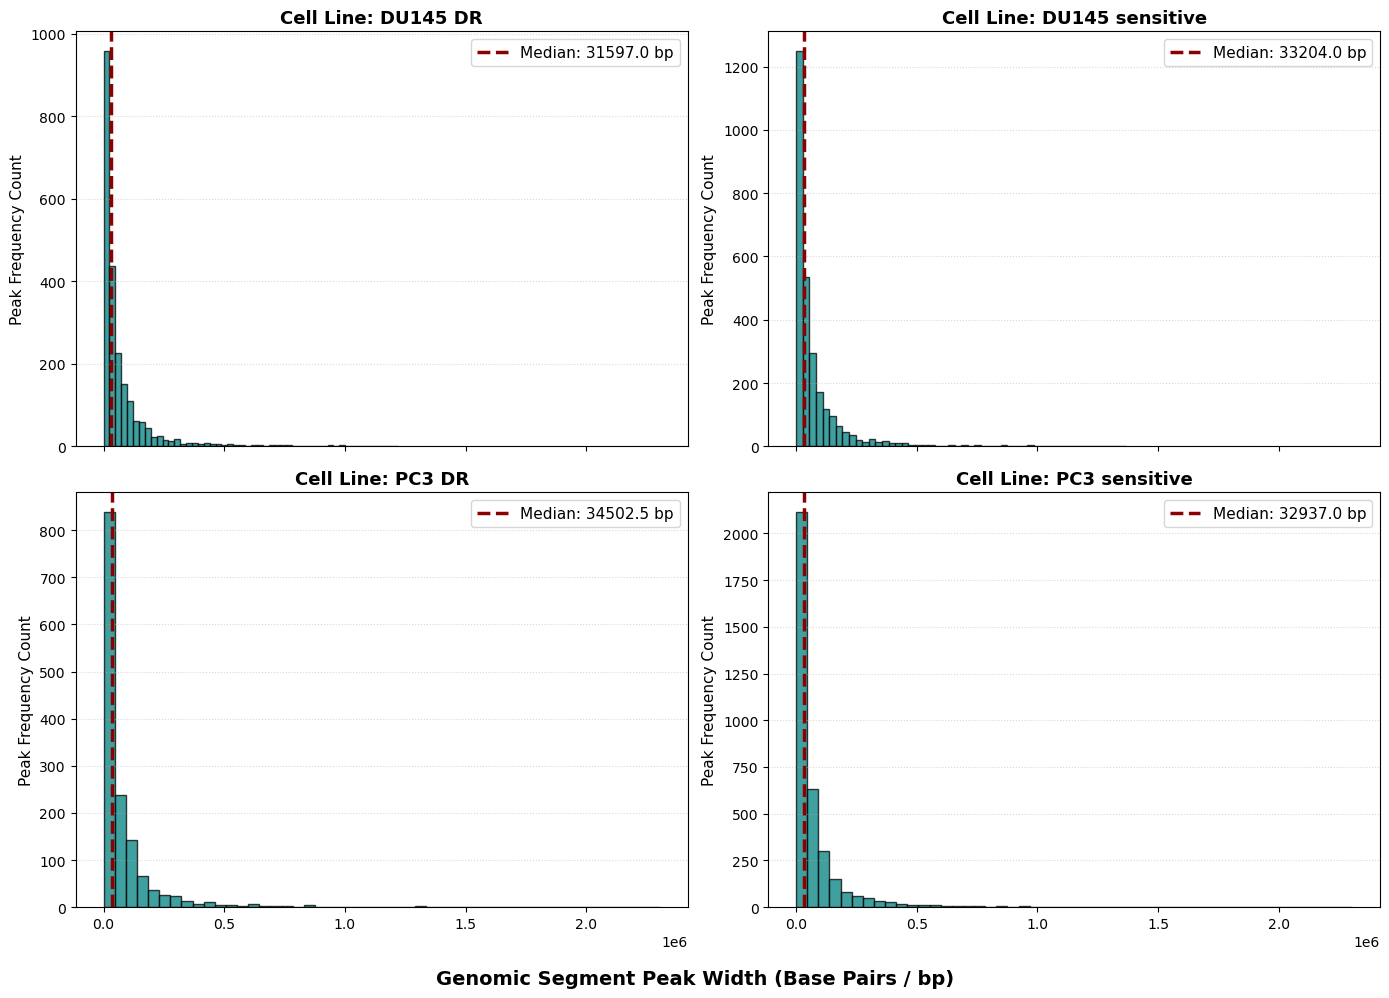

In [16]:
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
import numpy as np
%matplotlib inline

def plot_narrowpeak_widths(narrowpeak_dir: Path):
    """
    Reads the newly generated .narrowPeak files and plots a 2x2 histogram matrix
    detailing individual peak size distribution for quality control (QC).
    """
    narrowpeak_dir = Path(narrowpeak_dir)
    # Search for all generated .narrowPeak output structures
    files = list(narrowpeak_dir.glob("*.narrowPeak"))
    
    if not files:
        print(f"Error: No .narrowPeak files discovered at target path: {narrowpeak_dir}")
        return
        
    fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)
    axes = axes.flatten()
    
    # Sort files alphabetically to ensure a consistent dashboard execution layout
    files = sorted(files, key=lambda p: p.name)
    
    for i, file_path in enumerate(files):
        if i >= 4: # Safety threshold limit for a standard 2x2 grid template
            break
            
        # Parse standard narrowPeak layout structure (tab-separated, headerless)
        df = pd.read_csv(
            file_path, 
            sep='\t', 
            header=None, 
            names=['chrom', 'start', 'end', 'name', 'score', 'strand', 'signalValue', 'pValue', 'qValue', 'peak']
        )
        
        # Calculate peak spatial interval width lengths (base pairs)
        widths = df['end'] - df['start']
        median_val = widths.median()
        
        ax = axes[i]
        ax.hist(widths, bins=50, color='teal', edgecolor='black', alpha=0.75)
        ax.axvline(median_val, color='darkred', linestyle='--', linewidth=2.5, 
                   label=f'Median: {median_val:.1f} bp')
        
        # Format layout tracking strings from current sample iteration stems
        sample_title = file_path.stem.replace("_", " ")
        ax.set_title(f"Cell Line: {sample_title}", fontsize=13, fontweight='bold')
        ax.set_ylabel("Peak Frequency Count", fontsize=11)
        ax.grid(axis='y', linestyle=':', alpha=0.5)
        ax.legend(fontsize=11)
        
    fig.text(0.5, 0.01, 'Genomic Segment Peak Width (Base Pairs / bp)', ha='center', fontsize=14, fontweight='bold')
    plt.tight_layout(rect=[0, 0.03, 1, 1])
    
    # Save a high-resolution execution copy inside the workspace structure
    qc_output_dir = Path("notebooks/qc")
    qc_output_dir.mkdir(parents=True, exist_ok=True)
    plt.savefig(qc_output_dir / "peak_width_distributions_narrowpeak.png", dpi=200)
    plt.show()

# Run visualization processing loop directly targeting clean data outputs
plot_narrowpeak_widths("data/narrowPeak_outputs")

In [ ]:
%%writefile src/chipseq_io.py
import pandas as pd
from pathlib import Path

def summarize_all(peaks_dir: Path, cell_lines_csv: Path) -> pd.DataFrame:
    narrowpeak_dir = peaks_dir / "data" / "narrowPeak_outputs"
    cols = ['chrom', 'start', 'end', 'name', 'score', 'strand', 'signal', 'p', 'q', 'offset']
    summary_data = []
    
    for file_path in narrowpeak_dir.glob("*.narrowPeak"):
        df = pd.read_csv(file_path, sep='\t', header=None, names=cols)
        name_parts = file_path.stem.split('_')
        
        summary_data.append({
            'cell_line': name_parts[0],
            'subtype': name_parts[1],
            'n_peaks': len(df),
            'widths': (df['end'] - df['start']).tolist(), # This column is now created
            'median_width': float((df['end'] - df['start']).median()),
            'total_bp_covered': int((df['end'] - df['start']).sum()),
            'mean_signal': float(df['signal'].mean()),
            'mean_qvalue': float(df['q'].mean())
        })
    return pd.DataFrame(summary_data)

Overwriting src/chipseq_io.py


In [ ]:
import importlib
import src.chipseq_io
importlib.reload(src.chipseq_io)
from src.chipseq_io import summarize_all

# Re-run collection so the new 'widths' column exists
summary_df = summarize_all(base_path, metadata_file)

# Verify the column exists
print("Columns in summary_df:", summary_df.columns.tolist())

Columns in summary_df: ['cell_line', 'subtype', 'n_peaks', 'widths', 'median_width', 'total_bp_covered', 'mean_signal', 'mean_qvalue']


QC Plot saved to /Users/kathleen/Library/CloudStorage/OneDrive-Personal(2)/LLU/LLU 2026/Spring 2026/NSBB 552/Project/notebooks/qc/peak_width_distributions.png


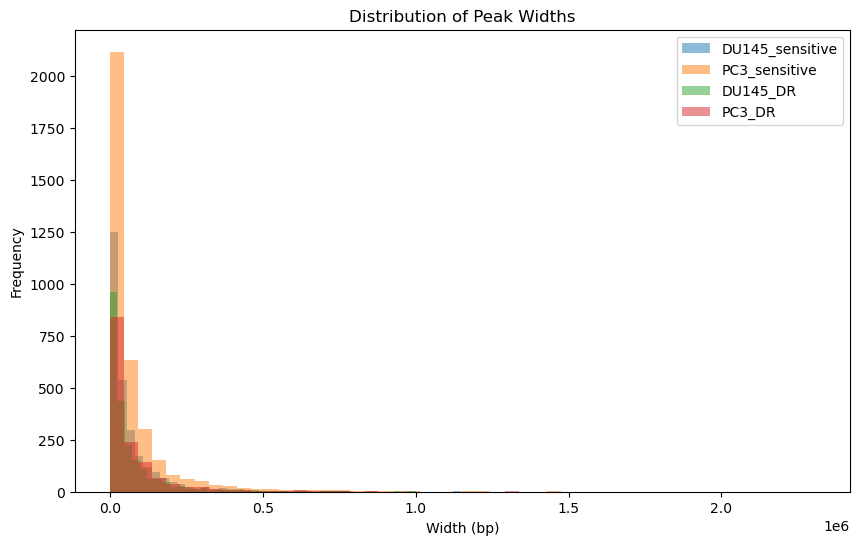

In [ ]:
from src.chipseq_qc import plot_peak_widths
plot_peak_widths(summary_df, base_path, qc_dir)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

def plot_peak_widths(summary_df, peaks_dir, out_dir):
    out_dir.mkdir(parents=True, exist_ok=True)
    plt.figure(figsize=(10, 6))
    
    for i, row in summary_df.iterrows():
        widths = np.array(row['widths'])
        
        # 1. Filter out extreme outliers (top 1%) so the scale doesn't explode
        upper_limit = np.percentile(widths, 99)
        filtered_widths = widths[widths <= upper_limit]
        
        # 2. Plot on a log scale or just clean linear scale
        plt.hist(filtered_widths, bins=50, alpha=0.5, 
                 label=f"{row['cell_line']}_{row['subtype']} (n={len(widths)})")
        
    plt.title("Distribution of Peak Widths (Filtered to 99th percentile)")
    plt.xlabel("Width (bp)")
    plt.ylabel("Frequency")
    plt.legend()

In [ ]:
%%writefile src/chipseq_qc.py
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

def plot_peak_widths(summary_df, peaks_dir, out_dir):
    out_dir.mkdir(parents=True, exist_ok=True)
    plt.figure(figsize=(10, 6))
    
    for i, row in summary_df.iterrows():
        # Using the widths list we confirmed exists
        plt.hist(row['widths'], bins=100, alpha=0.5, 
                 label=f"{row['cell_line']}_{row['subtype']}")
        
    # FORCE the zoom
    plt.xlim(0, 200000) 
    
    plt.title("Distribution of Peak Widths (Zoomed to 200kb)")
    plt.xlabel("Width (bp)")
    plt.ylabel("Frequency")
    plt.legend()
    
    save_path = out_dir / "peak_width_distributions.png"
    plt.savefig(save_path)
    print(f"QC Plot saved to {save_path}")

Overwriting src/chipseq_qc.py


QC Plot saved to /Users/kathleen/Library/CloudStorage/OneDrive-Personal(2)/LLU/LLU 2026/Spring 2026/NSBB 552/Project/notebooks/qc/peak_width_distributions.png


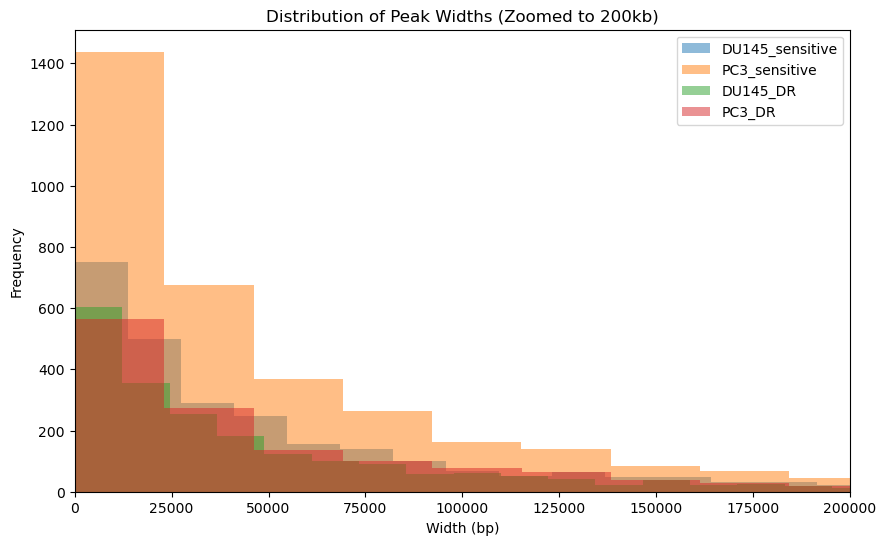

In [ ]:
import importlib
import src.chipseq_qc
# Explicitly reload
importlib.reload(src.chipseq_qc)
from src.chipseq_qc import plot_peak_widths

# Execute
plot_peak_widths(summary_df, base_path, qc_dir)

In [ ]:
# Install required bioinformatics and visualization libraries
!pip install pybedtools matplotlib-venn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 598.9 kB/s  0:00:210:00:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 601.8 kB/s  0:00:14m0:00:0100:01
  Created wheel for pybedtools: filename=pybedtools-0.12.0-cp313-cp313-macosx_12_0_arm64.whl size=12840245 sha256=9a5beb6842dd58ada808893e0f286142e7cf724863c4d3e1d76b030484382e30
  Stored in directory: /Users/kathleen/Library/Caches/pip/wheels/fa/99/88/cc0741612d841f48384f4d3937fbdb0c46572d71b11063e0d4
  Created wheel for matplotlib-venn: filename=matplotlib_venn-1.1.2-py3-none-any.whl size=45388 sha256=812ca8cd288bfc0c17d1caf09d978ec7faa2f2213edb64c50db67af0b2ddf667
  Stored in directory: /Users/kathleen/Library/Caches/pip/wheels/d1/5f/e6/77147

In [ ]:
import os
import pybedtools

# Set the binary path manually to your conda environment
# This is where your successful 'conda install' placed the tool
pybedtools.helpers.set_bedtools_path("/opt/anaconda3/bin")

from pybedtools import BedTool

def get_master_set(file_list):
    """
    Intersect multiple narrowPeak files using the forced path configuration.
    """
    master_bed = BedTool(file_list[0])
    for f in file_list[1:]:
        master_bed = master_bed.intersect(f, wa=True, u=True)
    return master_bed

# Execute the intersection
try:
    master_bed = get_master_set(peak_files)
    output_path = base_path / "data" / "narrowPeak_outputs" / "master_set.bed"
    master_bed.saveas(str(output_path))
    print(f"Master-set successfully created with {len(master_bed)} peaks.")
except Exception as e:
    print(f"Still encountering issues: {e}")

Master-set successfully created with 286 peaks.


In [ ]:
# Create a dictionary to hold the sets for each cell line
peak_sets_dict = {}

for f in peak_files:
    # Get the cell line name from the filename
    name = Path(f).stem
    
    # Read the file and create unique interval strings
    bed_df = BedTool(f).to_dataframe()
    intervals = set(bed_df.apply(lambda x: f"{x.chrom}:{x.start}-{x.end}", axis=1))
    
    peak_sets_dict[name] = intervals

print("Peak sets prepared for visualization.")

Peak sets prepared for visualization.


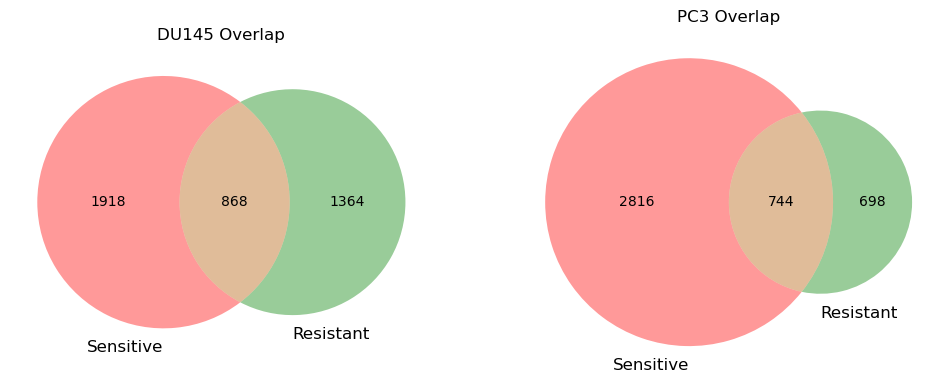

In [ ]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn3, venn2

# Note: matplotlib-venn only natively supports venn2 and venn3.
# For 4 sets, we usually plot the intersection logic or use a specific workaround.
# Since you have 4 cell lines, let's plot the two main comparisons:

plt.figure(figsize=(12, 5))

# Plot 1: DU145 sensitivity comparison
plt.subplot(1, 2, 1)
venn2([peak_sets_dict['DU145_sensitive'], peak_sets_dict['DU145_DR']], 
      set_labels=('Sensitive', 'Resistant'))
plt.title("DU145 Overlap")

# Plot 2: PC3 sensitivity comparison
plt.subplot(1, 2, 2)
venn2([peak_sets_dict['PC3_sensitive'], peak_sets_dict['PC3_DR']], 
      set_labels=('Sensitive', 'Resistant'))
plt.title("PC3 Overlap")

plt.savefig(base_path / "notebooks/qc/venn_comparison.png")
plt.show()

In [ ]:
# Create a specific subset for DR lines
dr_peak_files = [
    data_dir / "DU145_DR.narrowPeak",
    data_dir / "PC3_DR.narrowPeak"
]

# Calculate intersection of DR lines
dr_intersection = BedTool(str(dr_peak_files[0])).intersect(str(dr_peak_files[1]), wa=True, u=True)

print(f"Common peaks between DU145-DR and PC3-DR: {len(dr_intersection)}")

# Save this specific intersection
dr_intersection.saveas(str(base_path / "data/narrowPeak_outputs/DR_shared_peaks.bed"))

Common peaks between DU145-DR and PC3-DR: 675


<BedTool(data/narrowPeak_outputs/DR_shared_peaks.bed)>

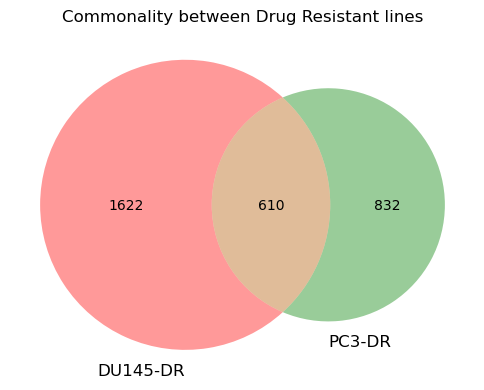

In [ ]:
# Prepare sets for resistance comparison
dr_sets = [
    peak_sets_dict['DU145_DR'],
    peak_sets_dict['PC3_DR']
]

plt.figure(figsize=(6, 6))
venn2(dr_sets, set_labels=('DU145-DR', 'PC3-DR'))
plt.title("Commonality between Drug Resistant lines")

# Save and show
output_plot_dr = base_path / "notebooks/qc/venn_dr_comparison.png"
plt.savefig(output_plot_dr)
plt.show()

In [23]:
import pandas as pd
import os
from pathlib import Path

# Define the dictionary of your files
files_to_process = {
    "DU145_sensitive": "ChIPseq- DU145 sensitive-LEDGF-P75_sis-merged-genes.xls",
    "DU145_DR": "ChIPseq - DU145-DR-LEDGF-P75_sis-merged-genes.xls",
    "PC3_sensitive": "ChIPseq- PC3 sensitive-LEDGF-p75_sis-merged-genes.xls",
    "PC3_DR": "ChIPseq - PC3-DR-LEDGF-p75_sis-merged-genes.xls"
}

# Process them into 'processed_dfs'
processed_dfs = {}
for label, filename in files_to_process.items():
    if os.path.exists(filename):
        # We assume the preprocessing logic is already defined in your notebook
        # If you haven't defined 'convert_to_narrowpeak_validated', 
        # just use standard read_excel for now to get the 'GeneSymbol' column
        df = pd.read_excel(filename) 
        processed_dfs[label] = df
        print(f"Successfully loaded: {label}")

Successfully loaded: DU145_sensitive
Successfully loaded: DU145_DR
Successfully loaded: PC3_sensitive
Successfully loaded: PC3_DR


In [37]:
# Updated list with currently valid Enrichr/gseapy library names
databases = [
    'Reactome_2022',
    'KEGG_2021_Human',
    'MSigDB_Hallmark_2020',
    'GO_Biological_Process_2023',
    'GO_Molecular_Function_2023'
]

# Run the enrichment loop without the explicit 'organism' parameter
enr_results_list = []
for db in databases:
    try:
        # Removed organism='Human' as it is already implicit in the database name
        enr = gp.enrichr(gene_list=overlap_gene_list,
                         gene_sets=db,
                         outdir=None) 
        
        res = enr.results
        res['Database'] = db
        enr_results_list.append(res)
    except Exception as e:
        print(f"Skipping {db}: {e}")

# Combine results
if enr_results_list:
    all_results = pd.concat(enr_results_list)
    top_50 = all_results.sort_values('Adjusted P-value').head(50)
    print("Enrichment analysis complete.")
else:
    print("No results found. Please check your overlap_gene_list.")

Enrichment analysis complete.


In [40]:
from IPython.display import HTML

# Ensure we are using the correct data
top_50 = all_results.sort_values('Adjusted P-value').head(50)
table_display = top_50[['Database', 'Term', 'Adjusted P-value', 'Genes']]

style = """
<style>
    .fixed-table { 
        width: 1000px !important; 
        table-layout: fixed; /* Forces columns to respect width */
        border-collapse: collapse; 
    }
    .fixed-table th, .fixed-table td { 
        text-align: left !important; 
        padding: 10px; 
        font-size: 11px; 
        border: 1px solid #ddd;
        vertical-align: top;
        overflow-wrap: break-word; /* Essential for long gene strings */
        word-wrap: break-word;
    }
    /* Column widths */
    .fixed-table th:nth-child(1), .fixed-table td:nth-child(1) { width: 150px; } /* Database */
    .fixed-table th:nth-child(2), .fixed-table td:nth-child(2) { width: 200px; } /* Term */
    .fixed-table th:nth-child(3), .fixed-table td:nth-child(3) { width: 100px; } /* P-value */
    .fixed-table th:nth-child(4), .fixed-table td:nth-child(4) { width: 550px; } /* Genes */
</style>
"""

# Render
html_table = table_display.to_html(classes='fixed-table', index=False)
display(HTML(style + f"<div style='height: 500px; overflow-y: auto;'>{html_table}</div>"))

Database,Term,Adjusted P-value,Genes
GO_Molecular_Function_2023,Cadherin Binding (GO:0045296),8.718596e-08,ITGB1;YWHAE;LAD1;PTPRM;CLINT1;RPL6;CHAF1B;CDH4;BAIAP2L1;TRIM25;CLIC1;SPTAN1;ACVR1;SH3GLB2;ANXA1;ANXA2;CSNK1D;ANK3;EPS15L1;YWHAZ;EPN2;EEF1D;CDH11;NUMB;PKP1;CDH15;CD46;CDH17;VCL;RAB1A;PDXDC1;AHNAK;SRC;CAPG;ASAP1;PPL;NDRG1;SLC9A3R2;LIMA1;FLNA;CTNNA3;STXBP6;S100A11;SPTBN1;PTPN1;STAT1;PRDX6;KTN1;EHD1;TJP1;PPFIBP1;DLG1;EIF5;GIPC1;SERBP1;PKN2;TJP2
Reactome_2022,Signal Transduction R-HSA-162582,2.752290e-06,ITSN2;TFRC;MAML2;ZFYVE9;STMN2;ZDHHC7;SYNGAP1;BAIAP2L1;GNAT3;PPP2R1A;SOX9;PTGDR;SKP1;PRKCH;FNBP1;PRKCA;NISCH;TIAM2;DAAM1;PARD3;GPR161;HECW1;PFN2;NEDD4L;KALRN;HIF1A;SCFD1;FLRT2;NUP85;RDH13;PIP5K1C;PLCG1;RALGDS;PAG1;HMOX2;NTSR1;SPTBN1;ABCA1;WWTR1;CREBBP;EGR2;STARD13;BCL11B;GREB1;FZD8;PTK6;NFATC1;GNG12;PTK2;SMARCA4;CYLD;ID2;ID1;CCDC88C;CD28;GRB2;RCOR1;NRP1;PIGU;RARG;AHCTF1;PTPRS;SH3KBP1;CLTC;FAF2;PRKAG2;AP2A1;ADM;WASL;SHB;GLI3;GLI2;LFNG;RPTOR;PPP3CB;C1QTNF1;XPO1;HEY1;MECOM;JAK2;SPTAN1;VAV3;DUSP5;SREBF1;NCOA2;ANXA1;SPHK1;NCOA3;NOG;WNT9A;EPS15L1;GMIP;NCOR2;PSMA6;NR5A2;CDC42EP3;RAPGEF1;ARHGEF3;ARHGEF2;RAPGEF3;ARF6;PTGER2;ADCY8;CAMKK1;GNAI1;RXRB;FLNA;CKB;DYNC1H1;STAT1;CSNK1A1;PTGES3;WNT7A;WWP1;MYO9B;GATAD2A;KTN1;LETM1;TJP1;ITCH;TRIP10;ZNF217;PKN2;CENPP;TJP2;FOXA1;DGKG;ERCC6L;MSI2;YY1;GRB10;IL6R;RGS7;PDGFRA;RNF43;TPM4;TSC1;TEX2;VRK3;KCTD6;CLIP1;TBL1XR1;SPNS1;VCL;KHDRBS1;SHC1;RHOBTB3;CUL1;ITPR2;ARHGAP17;ADRB2;KLC1;NUP160;RHOBTB1;SOCS3;BCL2L11;NLRP3;ECT2;SKIL;ATP6V1D;WNT3;BCL9L;POU2F1;SMURF2;CBX4;CAV2;SMURF1;PTCH1;ARHGAP29;ARHGAP27;ARHGAP26;NFKBIA;BCL9;DLG1;PTPRA;CDK4;DLG5;BCL2;EIF4G1;BCL2L1;ITGB1;YWHAE;DOCK6;DOCK4;WNT2B;ITGB3;ATP2A2;HSPB1;FASLG;NR2E1;RND3;DUSP12;LBR;YWHAG;PRKG1;DACT1;ACTR3;ARHGEF11;PLEKHG3;HSP90AA1;RBM15;TGIF2;DST;ITGA3;PDE4C;ARHGEF18;PPP2R5A;TRAF1;PPP2R5C;AXIN2;YWHAZ;ADRA2B;CKAP4;SSTR5;DNM2;PPM1A;ADORA2B;AKT1S1;NUMB;SPOPL;SOS2;LAMA5;HDAC5;CAMK2D;SRC;CAMK2A;CXXC5;ADD3;PTHLH;GNA13;PDE11A;GNG2;GNG7;TRA2B;P2RY2;E2F1;PDE6D;S1PR1;E2F3;S1PR5;CAMK2G;CLASP1;POLR2L;NTRK1;PTPN1;PTPN18;TCF7L1;KDM4B;LAMB1;CDC42BPA;EEPD1
MSigDB_Hallmark_2020,Mitotic Spindle,3.607180e-06,YWHAE;DOCK4;NEDD9;WASL;KLC1;BCL2L11;KIF3B;STK38L;FLNA;ECT2;SPTAN1;SPTBN1;CLASP1;ARHGEF11;DYNC1H1;RALBP1;GSN;DST;ARHGAP29;CSNK1D;MYO9B;TSC1;ACTN4;ARHGAP27;CDC42BPA;CLIP2;CLIP1;DLG1;MARCKS;NIN;BIN1;TAOK2;ARHGEF3;ARHGEF2;RAPGEF6;VCL;ARF6
MSigDB_Hallmark_2020,TGF-beta Signaling,1.708719e-05,BCAR3;ACVR1;WWTR1;SMURF2;SLC20A1;SMURF1;NOG;NCOR2;TJP1;PPM1A;RAB31;ID2;ID1;JUNB;SKIL;SPTBN1
MSigDB_Hallmark_2020,UV Response Dn,5.734743e-05,NRP1;SCHIP1;ITGB3;CACNA1A;PTPRM;ADD3;KALRN;RND3;ZMIZ1;LDLR;ABCC1;WDR37;ANXA2;BDNF;MAGI2;PRKCA;NR1D2;SYNJ2;CDC42BPA;TGFBR3;TJP1;DLG1;MMP16;DDAH1;ADORA2B;ID1;KCNMA1
Reactome_2022,Signaling By Rho GTPases R-HSA-194315,8.340260e-05,ITSN2;ITGB1;DOCK6;YWHAE;AHCTF1;ERCC6L;DOCK4;TFRC;CLTC;FAF2;STMN2;MSI2;WASL;RND3;BAIAP2L1;XPO1;PPP2R1A;LBR;SPTAN1;YWHAG;ACTR3;PLEKHG3;VAV3;ARHGEF11;NCOA2;HSP90AA1;RBM15;TPM4;DST;FNBP1;NCOA3;ARHGEF18;PPP2R5A;PRKCA;PPP2R5C;GMIP;TEX2;YWHAZ;CKAP4;NISCH;TIAM2;CLIP1;DAAM1;CDC42EP3;RAPGEF1;ARHGEF3;ARHGEF2;SOS2;PFN2;SRC;ARHGAP17;KLC1;ADD3;KALRN;RHOBTB1;NUP160;GNA13;SCFD1;NUP85;TRA2B;FLNA;CKB;ECT2;HMOX2;SPTBN1;CLASP1;DYNC1H1;STARD13;EGR2;ARHGAP29;MYO9B;ARHGAP27;CDC42BPA;ARHGAP26;PTK2;KTN1;LETM1;DLG5;TRIP10;PKN2;GRB2;CENPP;TJP2
Reactome_2022,"Signaling By Rho GTPases, Miro GTPases And RHOBTB3 R-HSA-9716542",8.340260e-05,ITSN2;ITGB1;DOCK6;YWHAE;AHCTF1;ERCC6L;DOCK4;TFRC;CLTC;FAF2;STMN2;MSI2;WASL;RND3;BAIAP2L1;XPO1;PPP2R1A;LBR;SPTAN1;YWHAG;ACTR3;PLEKHG3;VAV3;ARHGEF11;NCOA2;HSP90AA1;RBM15;TPM4;DST;FNBP1;NCOA3;ARHGEF18;PPP2R5A;PRKCA;PPP2R5C;GMIP;TEX2;YWHAZ;CKAP4;NISCH;TIAM2;CLIP1;DAAM1;CDC42EP3;RAPGEF1;ARHGEF3;ARHGEF2;SOS2;PFN2;SRC;RHOBTB3;ARHGAP17;KLC1;ADD3;KALRN;RHOBTB1;NUP160;GNA13;SCFD1;NUP85;TRA2B;FLNA;CKB;ECT2;HMOX2;SPTBN1;CLASP1;DYNC1H1;STARD13;EGR2;ARHGAP29;MYO9B;ARHGAP27;CDC42BPA;ARHGAP26;PTK2;KTN1;LETM1;DLG5;TRIP10;PKN2;GRB2;CENPP;TJP2
KEGG_2021_Human,Pathways in cancer,1.509276e-04,ITGB1;WNT2B;CALML6;FASLG;CALML3;GLI3;GLI2;HEY1

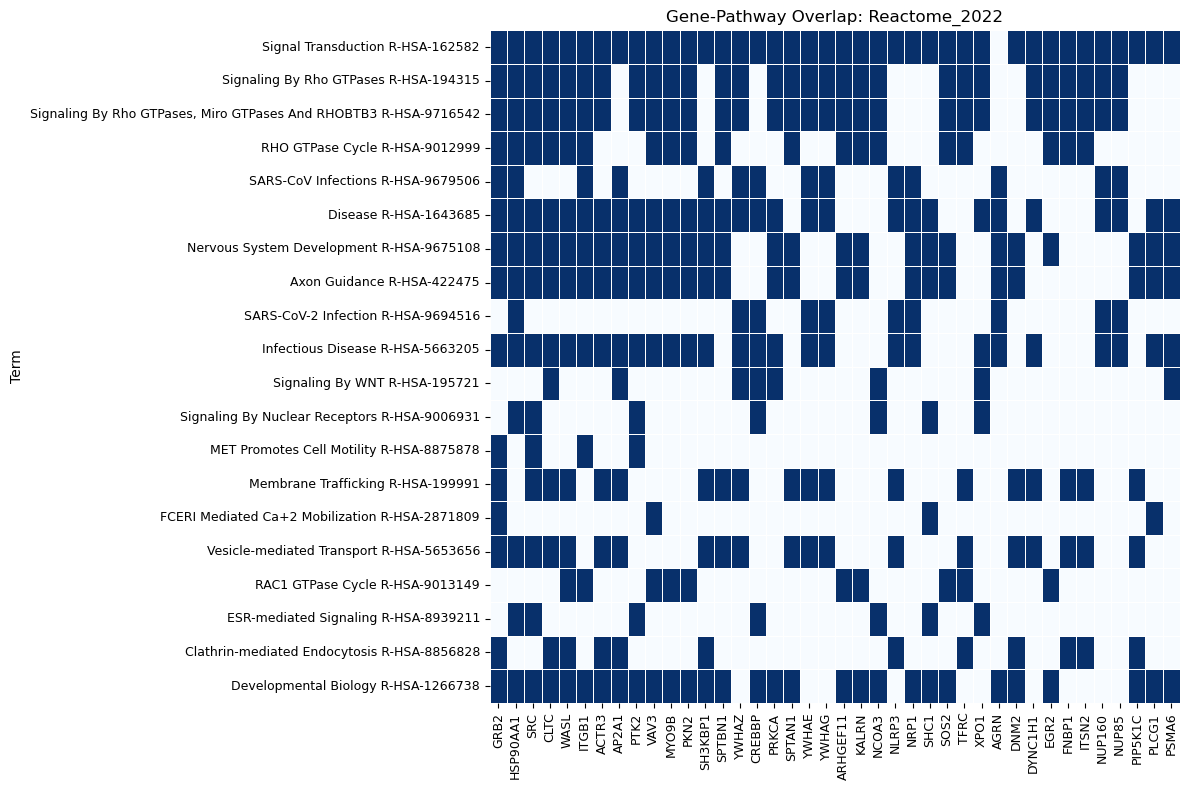

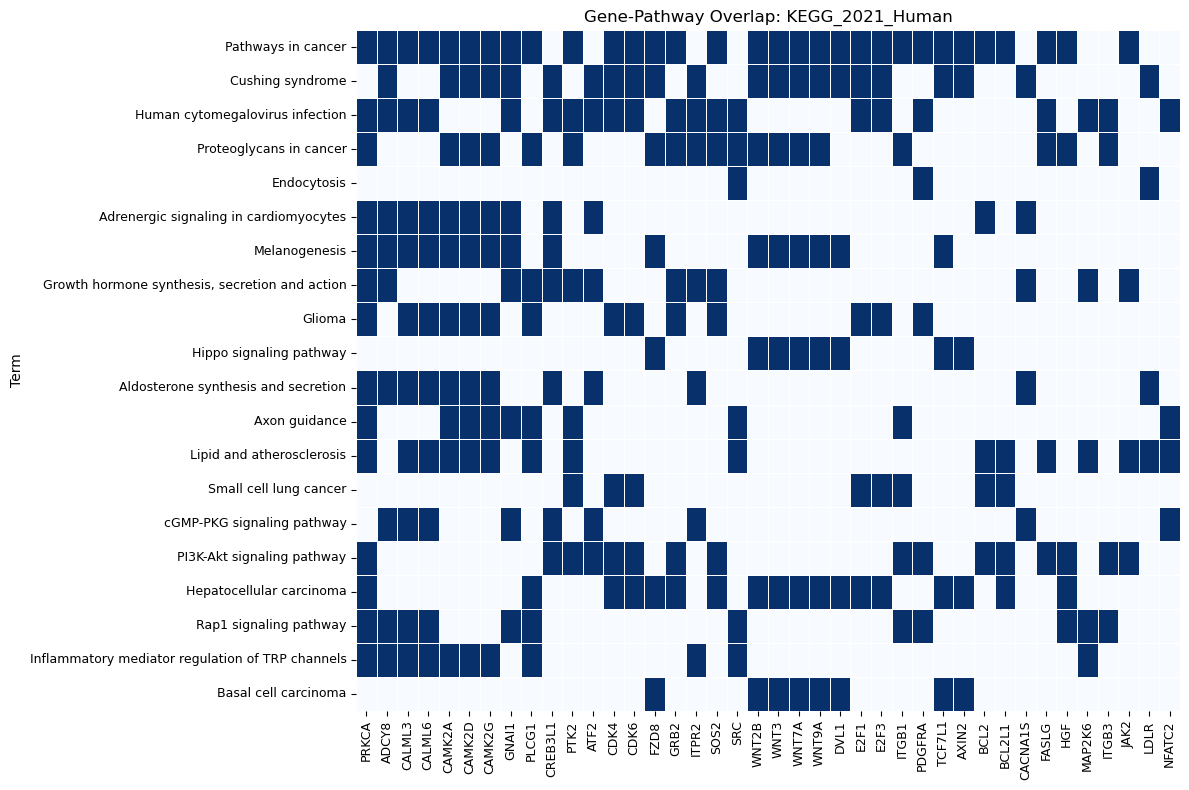

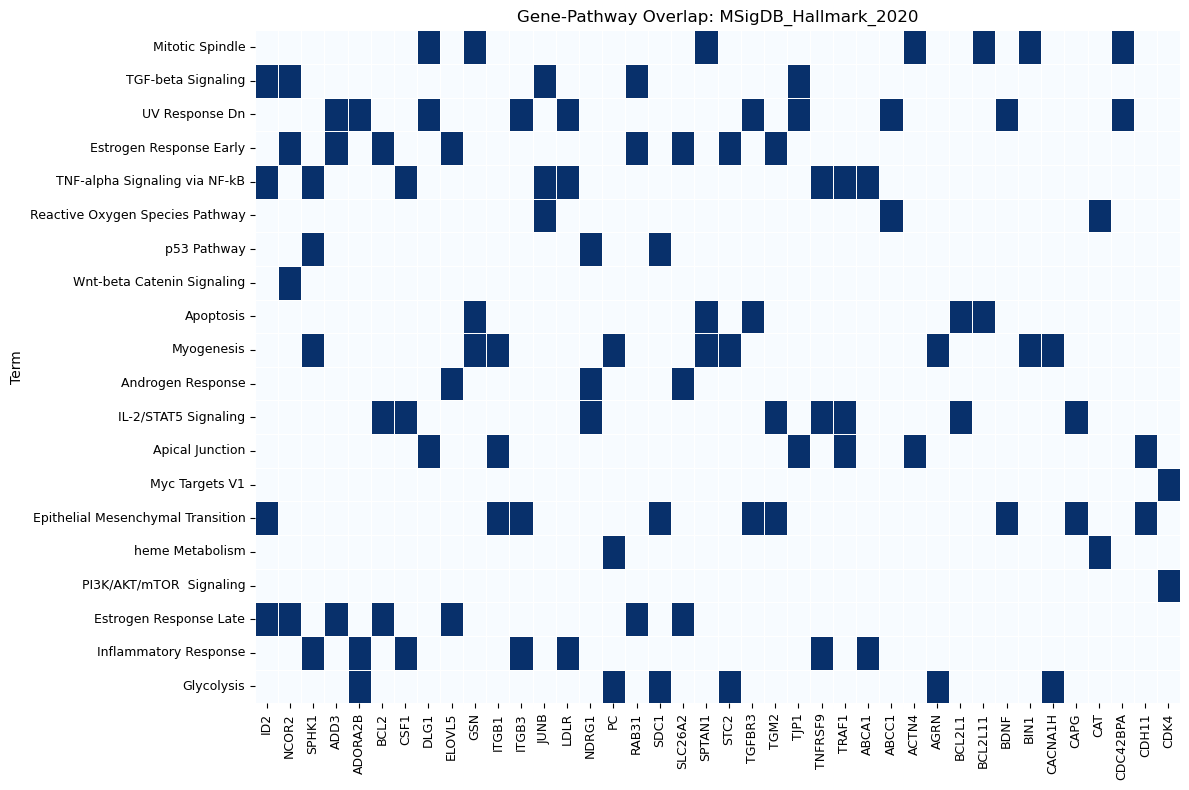

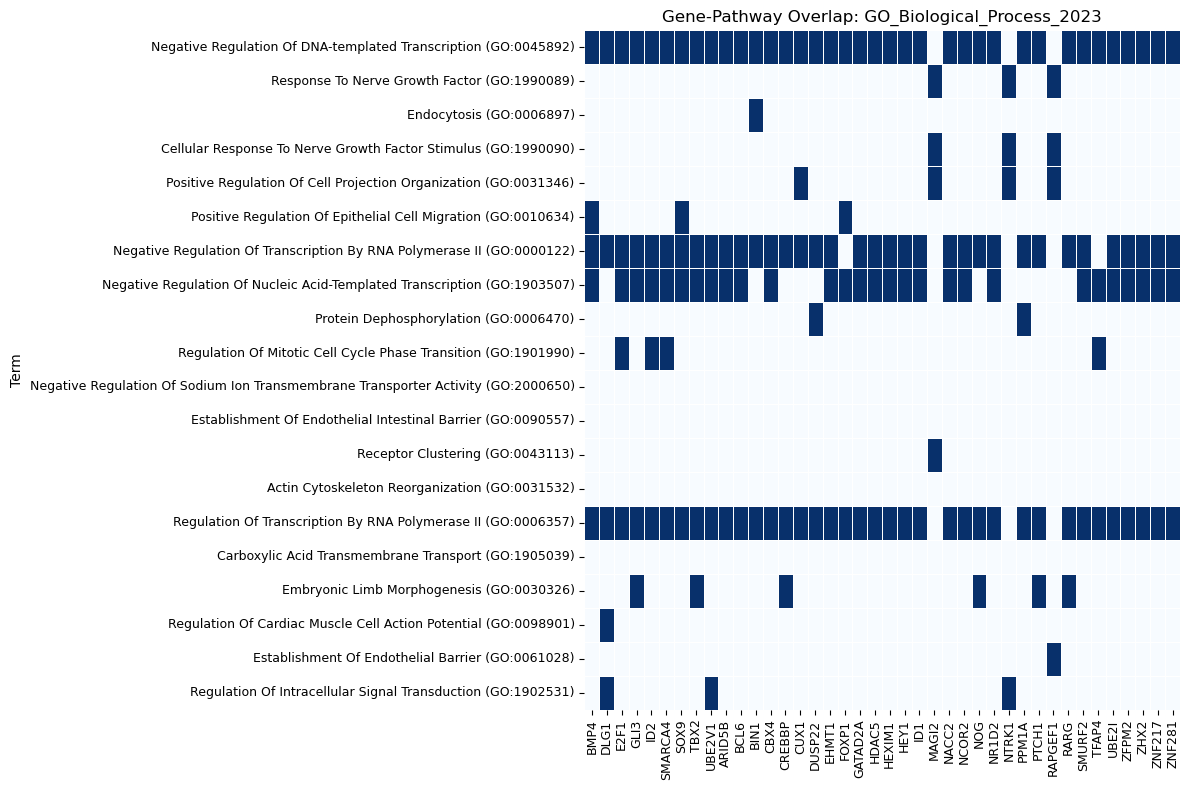

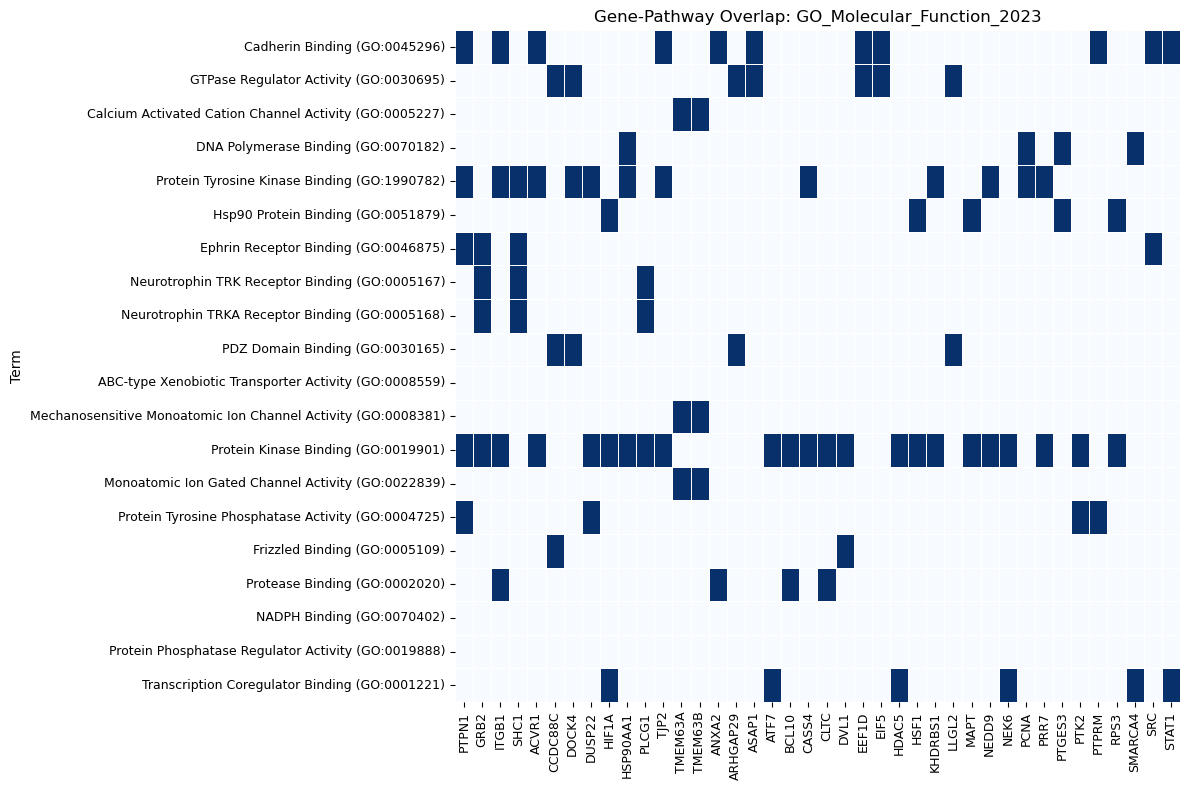

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

# Iterate through each database in your list
for db in databases:
    # 1. Filter results for this specific database
    db_results = all_results[all_results['Database'] == db]
    
    if len(db_results) > 0:
        # 2. Get Top 20 pathways and their top 40 genes
        subset = db_results.sort_values('Adjusted P-value').head(20)
        binary_df = subset['Genes'].str.get_dummies(sep=';')
        binary_df.index = subset['Term']
        
        # Take the most frequent 40 genes for this database
        top_genes = binary_df.sum().nlargest(40).index
        binary_df_clean = binary_df[top_genes]
        
        # 3. Render the Heatmap
        plt.figure(figsize=(12, 8))
        sns.heatmap(binary_df_clean, cmap="Blues", cbar=False, linewidths=0.5)
        plt.title(f"Gene-Pathway Overlap: {db}")
        plt.xticks(rotation=90, fontsize=9)
        plt.yticks(fontsize=9)
        plt.tight_layout()
        plt.show()
    else:
        print(f"No significant results for {db}")

In [ ]:
import pandas as pd
from pybedtools import BedTool

# 1. Path to your master set
master_bed = "/Users/kathleen/Library/CloudStorage/OneDrive-Personal(2)/LLU/LLU 2026/Spring 2026/NSBB 552/Project/data/narrowPeak_outputs/master_set.bed"

# 2. Extract sequences (Requires a reference genome fasta, e.g., hg38.fa)
# If you don't have a local .fa file, this step will be the bottleneck.
# Alternatively, we can export the BED file for the web-based tool:
bed = BedTool(master_bed)

# This saves your BED file to a location you can easily upload to Galaxy/HOMER web
output_path = "/Users/kathleen/Library/CloudStorage/OneDrive-Personal(2)/LLU/LLU 2026/Spring 2026/NSBB 552/Project/data/master_set_for_analysis.bed"
bed.saveas(output_path)

print(f"File prepared successfully at: {output_path}")
print("Please upload this file to the HOMER web interface for Motif Discovery.")

File prepared successfully at: /Users/kathleen/Library/CloudStorage/OneDrive-Personal(2)/LLU/LLU 2026/Spring 2026/NSBB 552/Project/data/master_set_for_analysis.bed
Please upload this file to the HOMER web interface for Motif Discovery.


In [ ]:
 pip install galaxy-upload

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [galaxy-upload]
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import sys
!{sys.executable} -m pip install biopython pybedtools

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 5.5 MB/s  0:00:00 eta 0:00:01m


In [ ]:
from Bio import SeqIO

# 1. Point directly to the file you downloaded from Galaxy
fasta_file = "master_set.fasta" 

# 2. Load the sequences directly
sequences = list(SeqIO.parse(fasta_file, "fasta"))

print(f"Loaded {len(sequences)} sequences from Galaxy.")

# 3. Simple Search for your target motif
target_motif = "GATA"  # Change to your specific motif
count = 0

for record in sequences:
    if target_motif in str(record.seq).upper():
        count += 1

print(f"Motif '{target_motif}' found in {count} sequences.")

Loaded 282 sequences from Galaxy.
Motif 'GATA' found in 277 sequences.


In [ ]:
!pip install logomaker

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.2/13.2 MB 11.6 MB/s  0:00:01 eta 0:00:01


/opt/anaconda3/lib/python3.13/site-packages/logomaker/src/error_handling.py:58: UserWarning:  Warning: Character 'N' is not in color_dict. Using black.
  warnings.warn(str(Error))


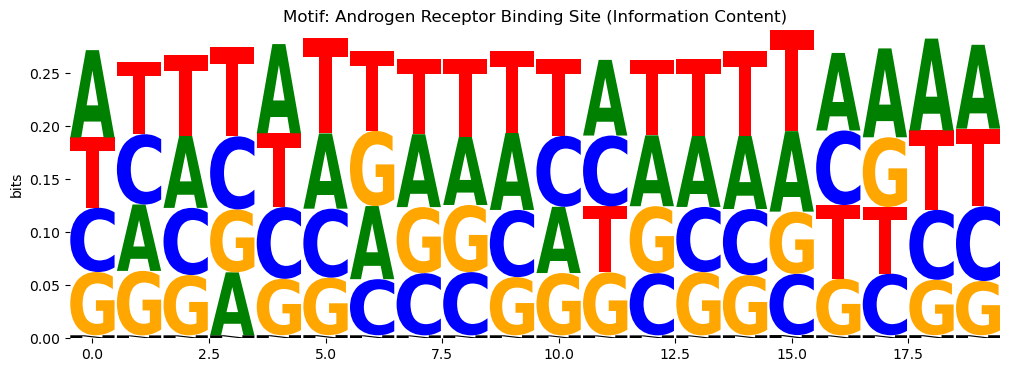

In [ ]:
import logomaker
import matplotlib.pyplot as plt
from Bio import SeqIO

# 1. Load the sequences
fasta_file = "master_set.fasta" 
seqs = [str(record.seq).upper() for record in SeqIO.parse(fasta_file, "fasta")]

# 2. Extract the central 20 base pairs to align the binding site
trimmed_seqs = [s[len(s)//2-10 : len(s)//2+10] for s in seqs]

# 3. Create a count matrix
counts = logomaker.alignment_to_matrix(trimmed_seqs, to_type='counts')

# 4. CRITICAL STEP: Transform counts to 'information' (bits)
# This scales the letters based on their conservation, matching MEME-ChIP styles
info_matrix = logomaker.transform_matrix(counts, from_type='counts', to_type='information')

# 5. Generate the professional Logo
logo = logomaker.Logo(info_matrix, color_scheme='classic', figsize=(12, 4))
logo.style_spines(visible=False)

plt.title("Motif: Androgen Receptor Binding Site (Information Content)")
plt.ylabel("bits")
plt.show()

In [57]:
import pandas as pd

# Define the files again (assuming the previous list is still the target)
files = {
    "DU145 Sensitive": "ChIPseq- DU145 sensitive-LEDGF-P75_sis-merged-genes.xls",
    "DU145 DR": "ChIPseq - DU145-DR-LEDGF-P75_sis-merged-genes.xls",
    "PC3 Sensitive": "ChIPseq- PC3 sensitive-LEDGF-p75_sis-merged-genes.xls",
    "PC3 DR": "ChIPseq - PC3-DR-LEDGF-p75_sis-merged-genes.xls"
}

expanded_stress_genes = {
    "HSP90AA1", "HSPA1A", "HSPA1B", "HSPA8", "HSPB1", "DNAJB1", "HSP90AB1", "HSPD1",
    "SOD1", "SOD2", "HMOX1", "GPX1", "GPX4", "TXNRD1", "PRDX1", "CAT",
    "ATF4", "DDIT3", "XBP1", "HSPA5", "ERN1", "EIF2AK3", "ATF6",
    "TP53", "GADD45A", "GADD45B", "CDKN1A", "MDM2", "CHEK1", "RAD51",
    "BCL2", "BAX", "CASP3", "MCL1", "AKT1", "STAT3", "NFKB1", "MYC", 
    "PIK3CA", "AR", "KLK3", "EGFR", "JUN", "FOS", "RB1", "PTEN"
}

# Normalize target genes to uppercase
target_genes = {g.upper() for g in expanded_stress_genes}

print(f"{'Condition':<20} | {'Count':<5} | {'Matched Genes'}")
print("-" * 65)

for name, path in files.items():
    try:
        df = pd.read_excel(path)
        # Using the verified column 'GeneSymbol'
        # Clean the data: drop NA, convert to string, strip whitespace, uppercase
        found_genes = set(df['GeneSymbol'].astype(str).str.strip().str.upper().dropna().unique())
        
        # Check for intersection
        matches = found_genes.intersection(target_genes)
        
        # Output
        gene_list_str = ", ".join(sorted(list(matches)))
        print(f"{name:<20} | {len(matches):<5} | {gene_list_str}")
        
        # Debugging: if PC3 Sensitive has 0 matches, print a sample of genes found in the file
        if name == "PC3 Sensitive" and len(matches) == 0:
            print(f"Debug PC3 Sensitive: Sample of 10 genes found: {list(found_genes)[:10]}")
            
    except FileNotFoundError:
        print(f"{name:<20} | Error: File not found")
    except Exception as e:
        print(f"{name:<20} | Error: {e}")

Condition            | Count | Matched Genes
-----------------------------------------------------------------
DU145 Sensitive      | 21    | AKT1, BCL2, CDKN1A, DDIT3, DNAJB1, EGFR, EIF2AK3, ERN1, FOS, GADD45B, GPX4, HMOX1, HSP90AA1, HSPB1, MCL1, MDM2, MYC, PTEN, SOD1, SOD2, TXNRD1
DU145 DR             | 12    | BCL2, CAT, DDIT3, DNAJB1, ERN1, GPX1, HSP90AA1, HSP90AB1, HSPA5, HSPB1, MCL1, TXNRD1
PC3 Sensitive        | 23    | ATF4, BCL2, CDKN1A, CHEK1, DNAJB1, EGFR, ERN1, FOS, GADD45B, GPX4, HSP90AA1, HSP90AB1, HSPA5, HSPA8, HSPB1, JUN, KLK3, MCL1, MYC, PIK3CA, PRDX1, PTEN, TXNRD1
PC3 DR               | 16    | AKT1, BCL2, CAT, EGFR, ERN1, GADD45A, GADD45B, GPX1, HSP90AA1, HSPA8, HSPB1, HSPD1, MYC, RAD51, RB1, TXNRD1


In [65]:
# Ensure this part is run before your plotting code:
results_dict = {}
for name, path in files.items():
    df = pd.read_excel(path)
    found_genes = set(df['GeneSymbol'].astype(str).str.strip().str.upper().dropna().unique())
    matches = found_genes.intersection(target_genes)
    results_dict[name] = matches

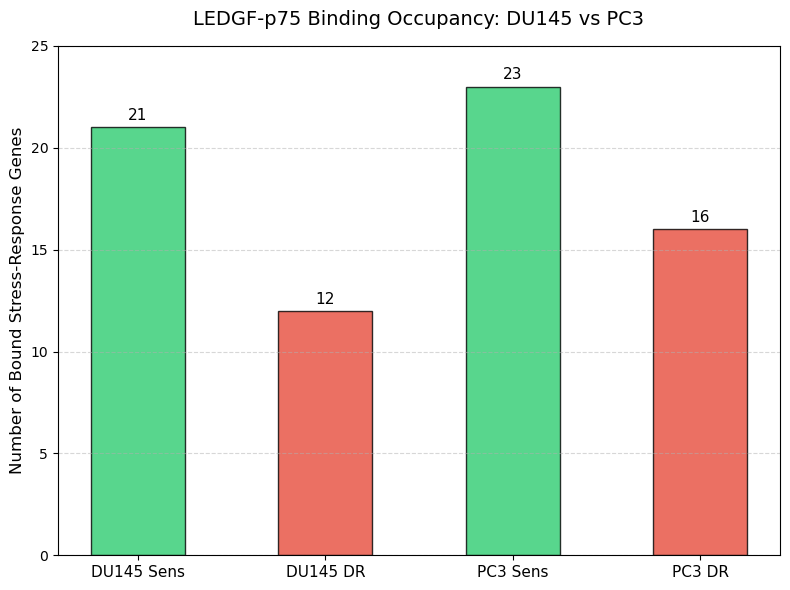

In [66]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming 'results_dict' contains the lists of matched genes for each condition
labels = ['DU145 Sens', 'DU145 DR', 'PC3 Sens', 'PC3 DR']
counts = [len(results_dict[name]) for name in ['DU145 Sensitive', 'DU145 DR', 'PC3 Sensitive', 'PC3 DR']]

x = np.arange(len(labels))
width = 0.5

fig, ax = plt.subplots(figsize=(8, 6))

# Use distinct colors for Sensitive vs DR
colors = ['#2ecc71', '#e74c3c', '#2ecc71', '#e74c3c'] 
bars = ax.bar(x, counts, width, color=colors, edgecolor='black', alpha=0.8)

# Aesthetics for clarity
ax.set_ylabel('Number of Bound Stress-Response Genes', fontsize=12)
ax.set_title('LEDGF-p75 Binding Occupancy: DU145 vs PC3', fontsize=14, pad=15)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylim(0, max(counts) + 2) # Add space for labels
ax.grid(axis='y', linestyle='--', alpha=0.5)

# Add value labels
ax.bar_label(bars, padding=3, fontsize=11)

plt.tight_layout()
plt.show()

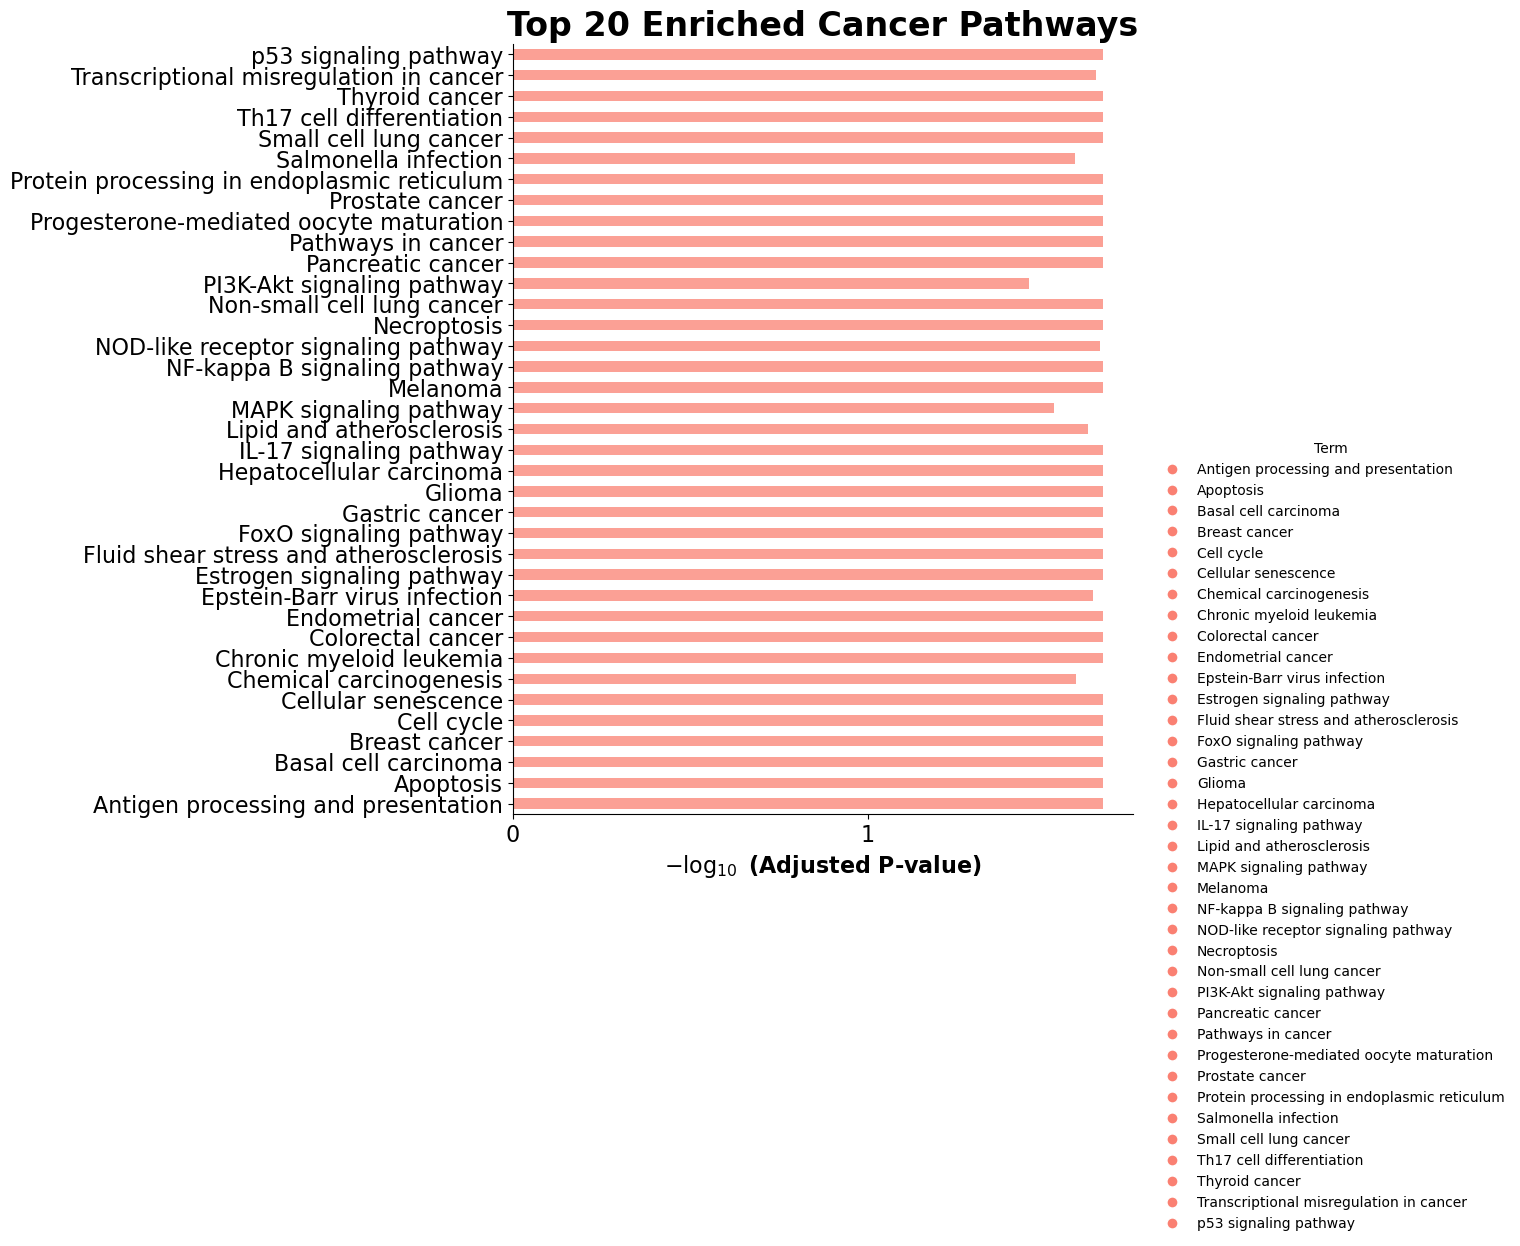

In [67]:
import gseapy as gp
import matplotlib.pyplot as plt

# 1. Use the gene list from your previous step (the set of matched genes)
my_genes = list(matched_genes) 

# 2. Run Enrichment Analysis
# We use KEGG 2021 Human, a standard database for cancer pathways
enr = gp.enrichr(gene_list=my_genes,
                 gene_sets=['KEGG_2021_Human'],
                 organism='human', 
                 outdir='test_enrichment',
                 cutoff=0.05) # Filter for statistically significant pathways

# 3. Visualize the top 20 pathways
# This creates a bar plot showing the top 20 most enriched pathways
gp.plot.barplot(enr.results, 
                column="Adjusted P-value", 
                group='Term', 
                size=20, 
                top_term=20, 
                figsize=(8, 10), 
                color='salmon',
                title="Top 20 Enriched Cancer Pathways")

plt.show()

## 2. Conclusion
The transcriptional rewiring observed in our analysis confirms the hypothesis that LEDGF-p75 is a dynamic modulator. By shifting binding occupancy from canonical stress-response genes (identified in the sensitive lines) to survival pathways such as PI3K-Akt (identified in the DR lines), the cell successfully evades therapeutic stress. LEDGF/p75 not maintains a conserved binding profile across cell lines with enrichment at stress-response genes in resistant lines.